In [4]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
import cartopy.feature as cfeature
import os
from datetime import datetime
import warnings
import math
warnings.filterwarnings('ignore')

# China boundary shapefiles
china_shape = './shapefiles/china.shp'
nine_dash_shape = './shapefiles/china_nine_dotted_line.shp'

def add_region_dividers(ax, extent=[105, 125]):
    # Add two light gray horizontal dashed lines marking approximate boundaries of three coastal regions
    ax.plot([extent[0], extent[1]], [24, 24],
            linestyle='--', linewidth=1.5, color='gray', alpha=0.9,
            transform=ccrs.PlateCarree())
    ax.plot([extent[0], extent[1]], [34, 34],
            linestyle='--', linewidth=1.5, color='gray', alpha=0.9,
            transform=ccrs.PlateCarree())

def _adjust_cbar_ticks(cbar, fontsize, step, ticks):
    """Helper function: adjust colorbar tick font size and interval"""
    if fontsize is not None:
        cbar.ax.tick_params(labelsize=fontsize)
    if ticks is not None:
        cbar.set_ticks(ticks)
    elif step is not None:
        import matplotlib.ticker as mticker
        cbar.locator = mticker.MultipleLocator(step)
        cbar.update_ticks()

def plot_precipitation_multi(file_list, titles=None, ncols=2, extent=[100, 135.5, 15, 50],
                             vmax=None, figsize=None, share_colorbar=True,
                             gridline_interval=10, label_fontsize=12,
                             cbar_pad=0.05, cbar_fraction=0.02, cbar_shrink=0.9,
                             orientation='vertical',                # new
                             cbar_tick_fontsize=None,               # new
                             cbar_tick_step=None,                   # new
                             cbar_ticks=None,                       # new (optional)
                             subplots_adjust=None):
    """
    Plot precipitation distributions for multiple files, arranged in a grid (optimized version).
    """
    n = len(file_list)
    nrows = math.ceil(n / ncols)
    
    if figsize is None:
        figsize = (6 * ncols, 5 * nrows)  # each subplot approx 6x5 inches
    
    fig, axes = plt.subplots(nrows, ncols, subplot_kw={'projection': ccrs.PlateCarree()},
                             figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
    
    # Hide extra subplots
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    
    # Title handling
    if titles is None:
        titles = [os.path.basename(f) for f in file_list]
    else:
        assert len(titles) == n, "titles length must match file_list"
    
    # ----- Handle vmax -----
    if share_colorbar:
        if vmax is None:
            all_precip = []
            for f in file_list:
                ds = xr.open_dataset(f)
                precip = ds['prec'].isel(time=0).values
                all_precip.append(precip.flatten())
                ds.close()
            all_precip = np.concatenate(all_precip)
            vmax_global = np.percentile(all_precip[~np.isnan(all_precip)], 99.9)
            print(f"Global auto-set vmax = {vmax_global:.1f} mm")
        else:
            vmax_global = vmax
        vmax_list = [vmax_global] * n
    else:
        if vmax is None:
            vmax_list = []
            for f in file_list:
                ds = xr.open_dataset(f)
                precip = ds['prec'].isel(time=0).values
                v = np.percentile(precip[~np.isnan(precip)], 99.9)
                vmax_list.append(v)
                ds.close()
            print("Auto-set vmax for each file:", [f"{v:.1f}" for v in vmax_list])
        elif isinstance(vmax, (int, float)):
            vmax_list = [vmax] * n
        elif isinstance(vmax, list):
            vmax_list = vmax
        else:
            raise ValueError("vmax should be None, a number, or a list")
    
    # Store plot objects for shared colorbar
    im_list = []
    
    for i, (ax, file, title, vm) in enumerate(zip(axes_flat[:n], file_list, titles, vmax_list)):
        # Read data
        ds = xr.open_dataset(file)
        precip = ds['prec'].isel(time=0)
        lon = ds.lon.values
        lat = ds.lat.values
        ds.close()
        
        # Set map extent
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Add region divider lines
        add_region_dividers(ax, extent=[0, 180])
        
        # Add China boundary and nine-dashed line
        ax.add_geometries(Reader(china_shape).geometries(),
                          ccrs.PlateCarree(), facecolor='none',
                          edgecolor='black', linewidth=0.8)
        ax.add_geometries(Reader(nine_dash_shape).geometries(),
                          ccrs.PlateCarree(), facecolor='none',
                          edgecolor='black', linewidth=0.8)
        
        # Plot precipitation
        cmap = plt.cm.Blues.copy()
        cmap.set_under('white')
        im = ax.pcolormesh(lon, lat, precip, cmap=cmap,
                           vmin=0.01, vmax=vm, shading='auto',
                           transform=ccrs.PlateCarree())
        im_list.append(im)
        
        # Determine current subplot position in the grid
        row = i // ncols
        col = i % ncols
        # Coordinate label control: only first column shows left labels, only last row shows bottom labels
        left_labels = (col == 0)
        bottom_labels = (row == nrows - 1)
        
        # Add gridlines and control label visibility
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                          linewidth=0, alpha=0,
                          xlocs=mticker.MultipleLocator(gridline_interval),
                          ylocs=mticker.MultipleLocator(gridline_interval))
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = left_labels
        gl.bottom_labels = bottom_labels
        # Set label font size
        gl.xlabel_style = {'size': label_fontsize}
        gl.ylabel_style = {'size': label_fontsize}
        
        # Title
        ax.set_title(title, fontsize=18, fontweight='bold')
        
        # Add South China Sea inset map
        ax_inset = ax.inset_axes([0.75, 0.001, 0.3, 0.3], transform=ax.transAxes,
                                 projection=ccrs.PlateCarree())
        ax_inset.set_extent([106.3, 122.8, 2.6, 25.2], crs=ccrs.PlateCarree())
        ax_inset.add_geometries(Reader(china_shape).geometries(),
                                ccrs.PlateCarree(), facecolor='none',
                                edgecolor='black', linewidth=0.5)
        ax_inset.add_geometries(Reader(nine_dash_shape).geometries(),
                                ccrs.PlateCarree(), facecolor='none',
                                edgecolor='black', linewidth=0.5)
        ax_inset.pcolormesh(lon, lat, precip, cmap=cmap, vmin=0, vmax=vm,
                            shading='auto', transform=ccrs.PlateCarree(), alpha=0.8)
        
        # If not sharing colorbar, add individual colorbar
        if not share_colorbar:
            cbar = fig.colorbar(im, ax=ax, orientation=orientation,   # use orientation parameter
                                pad=cbar_pad, shrink=cbar_shrink, extend='max', aspect=25,
                                fraction=cbar_fraction)
            # Set tick font size and interval
            _adjust_cbar_ticks(cbar, cbar_tick_fontsize, cbar_tick_step, cbar_ticks)
    
    # If sharing colorbar, add a global colorbar (manually create axis to ensure height matches all subplots)
    if share_colorbar and im_list:
        # First apply subplot layout adjustments
        if subplots_adjust is None:
            left = 0.08 + 0.02 * (ncols-1)
            right = 0.92 - 0.02 * (ncols-1) if ncols > 1 else 0.88
            subplots_adjust = {
                'left': left,
                'right': right,
                'bottom': 0.08,
                'top': 0.95,
                'wspace': 0.15,
                'hspace': 0.2
            }
        fig.subplots_adjust(**subplots_adjust)
        
        # Get bounding boxes of all valid subplots (relative to figure coordinates)
        bboxes = [ax.get_position() for ax in axes_flat[:n]]
        # Compute union
        x0 = min(bbox.x0 for bbox in bboxes)
        x1 = max(bbox.x1 for bbox in bboxes)
        y0 = min(bbox.y0 for bbox in bboxes)
        y1 = max(bbox.y1 for bbox in bboxes)
        
        # Determine colorbar width (based on fraction parameter) and spacing from subplots (pad)
        main_width = x1 - x0
        cbar_width = main_width * cbar_fraction
        cbar_x = x1 + cbar_pad * main_width
        cbar_y = y0
        cbar_height = y1 - y0
        
        # Create colorbar axis
        cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
        
        # Add colorbar
        cbar = fig.colorbar(im_list[0], cax=cax, orientation=orientation, extend='max')
        cbar.set_label('Precipitation (mm)', fontsize=14)
        
        # Set tick font size and interval
        _adjust_cbar_ticks(cbar, cbar_tick_fontsize, cbar_tick_step, cbar_ticks)

    
    plt.tight_layout()  # optional; subplots_adjust already adjusted, tight_layout may override, so commented out
    return fig

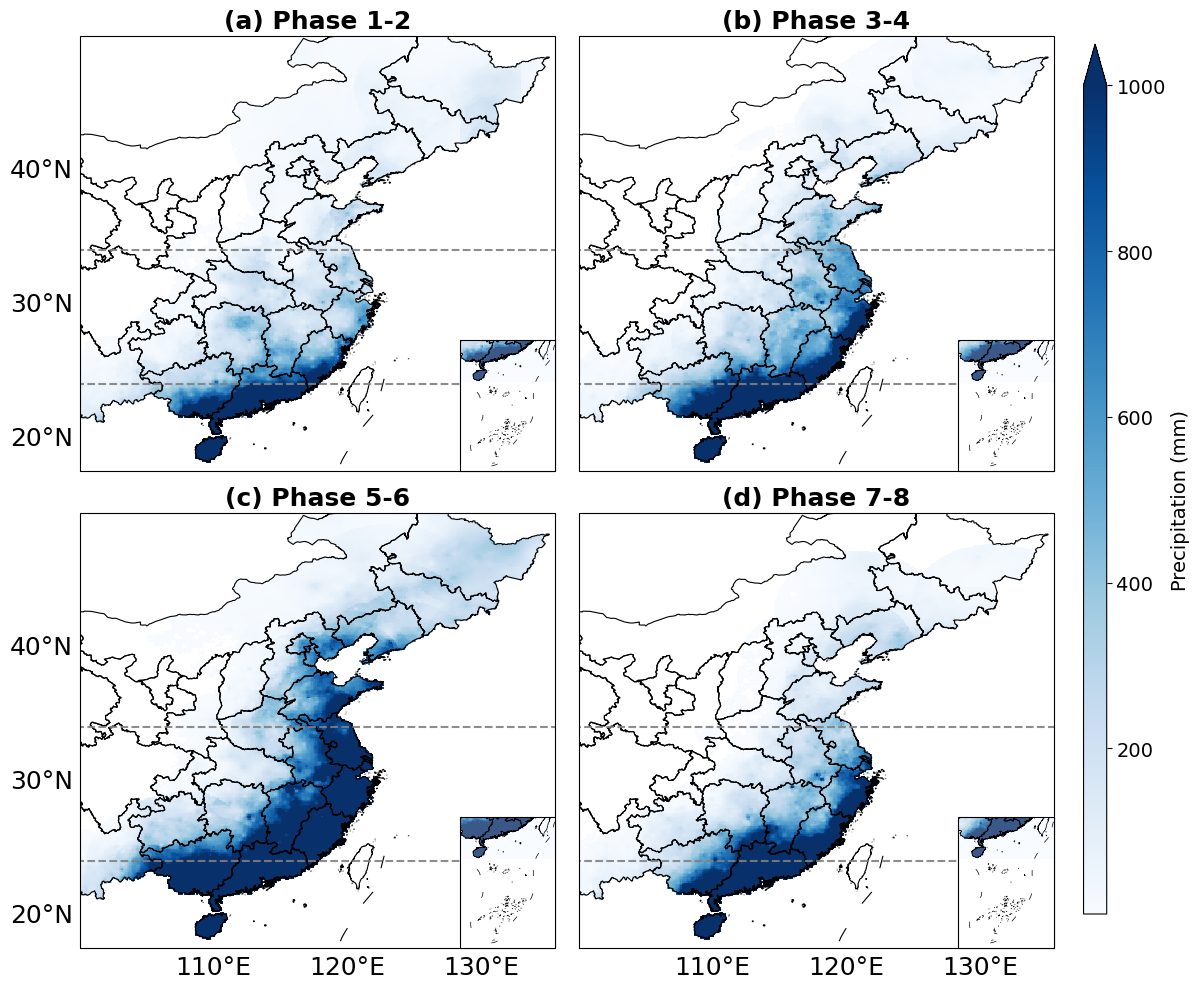

In [11]:

data = [
    {"file": "./01MJOpre_phase12.nc", "title": "(a) Phase 1-2"},
    {"file": "./01MJOpre_phase34.nc", "title": "(b) Phase 3-4"},
    {"file": "./01MJOpre_phase56.nc", "title": "(c) Phase 5-6"},
    {"file": "./01MJOpre_phase78.nc", "title": "(d) Phase 7-8"}
]

files = [item["file"] for item in data]
titles = [item["title"] for item in data]

fig = plot_precipitation_multi(
    files, titles=titles, ncols=2,
    extent=[100, 135.5, 17.5, 50],
    vmax=1000,
    share_colorbar=True,
    gridline_interval=10,
    label_fontsize=18,
    cbar_pad=0.2,
    cbar_fraction=0.03,
    cbar_shrink=0.88,          # 此参数在手动创建轴时不再使用，但可保留以防万一
    orientation='vertical',
    cbar_tick_fontsize=14,
    cbar_tick_step=200,
    subplots_adjust={'left':0.08, 'right':0.88, 'bottom':0.08, 'top':0.95, 'wspace':-0.5, 'hspace':0.1}
)
plt.savefig('5all.png', dpi=600, bbox_inches='tight')
plt.show()

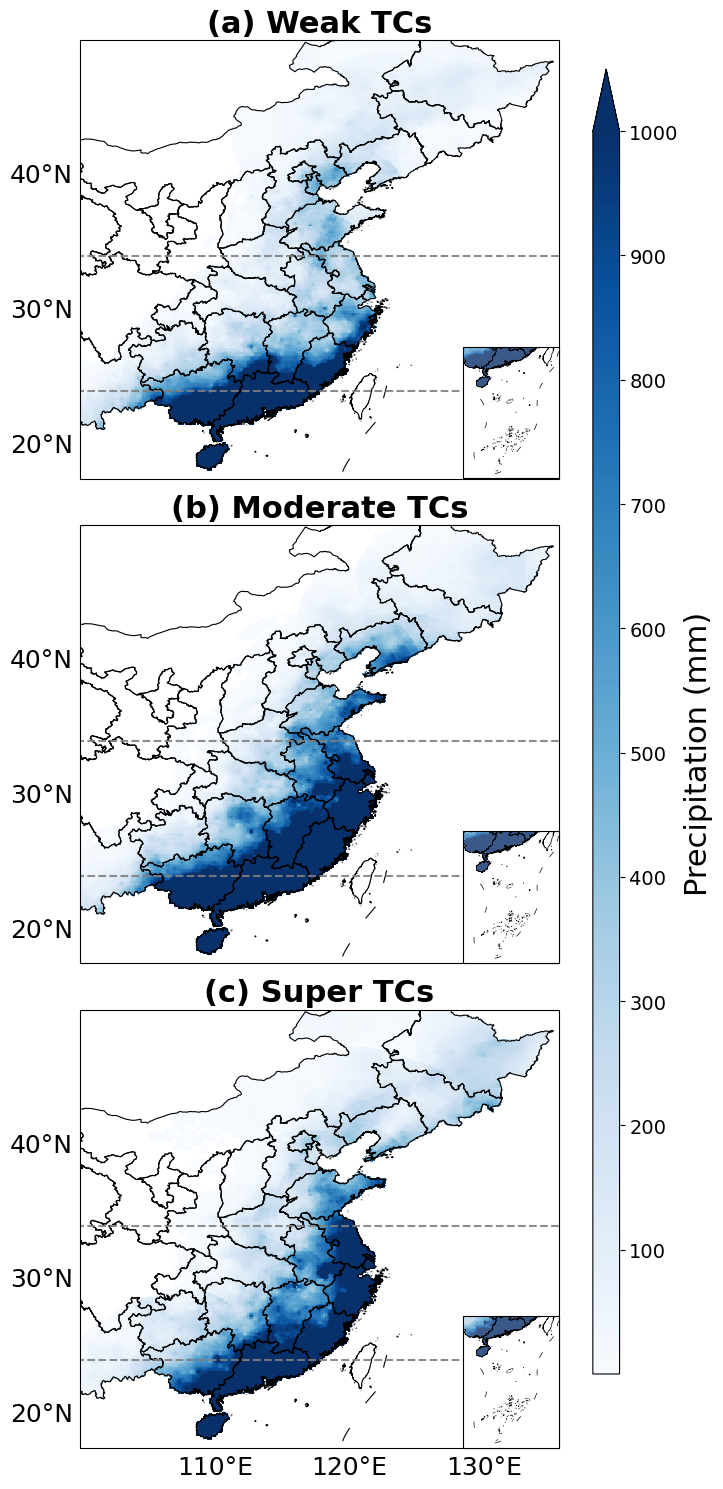

In [3]:

data = [
    {"file": "./03_storms.nc", "title": "(a) Weak TCs"},
    {"file": "./03_tcs.nc", "title": "(b) Moderate TCs"},
    {"file": "./03_super_tcs.nc", "title": "(c) Super TCs"},

]
files = [item["file"] for item in data]
titles = [item["title"] for item in data]

fig = plot_precipitation_multi(
    files, titles=titles, ncols=1,
    extent=[100, 135.5, 17.5, 50],
    vmax=1000,
    share_colorbar=True,
    gridline_interval=10,
    label_fontsize=18,
    cbar_pad=0.2,
    cbar_fraction=0.06,
    cbar_shrink=0.88,           
    orientation='vertical',
    cbar_tick_fontsize=14,
    cbar_tick_step=100,
    subplots_adjust={'left':0.08, 'right':0.88, 'bottom':0.08, 'top':0.95, 'wspace':-0.5, 'hspace':0.1}
)
plt.savefig('4all.png', dpi=600, bbox_inches='tight')
plt.show()

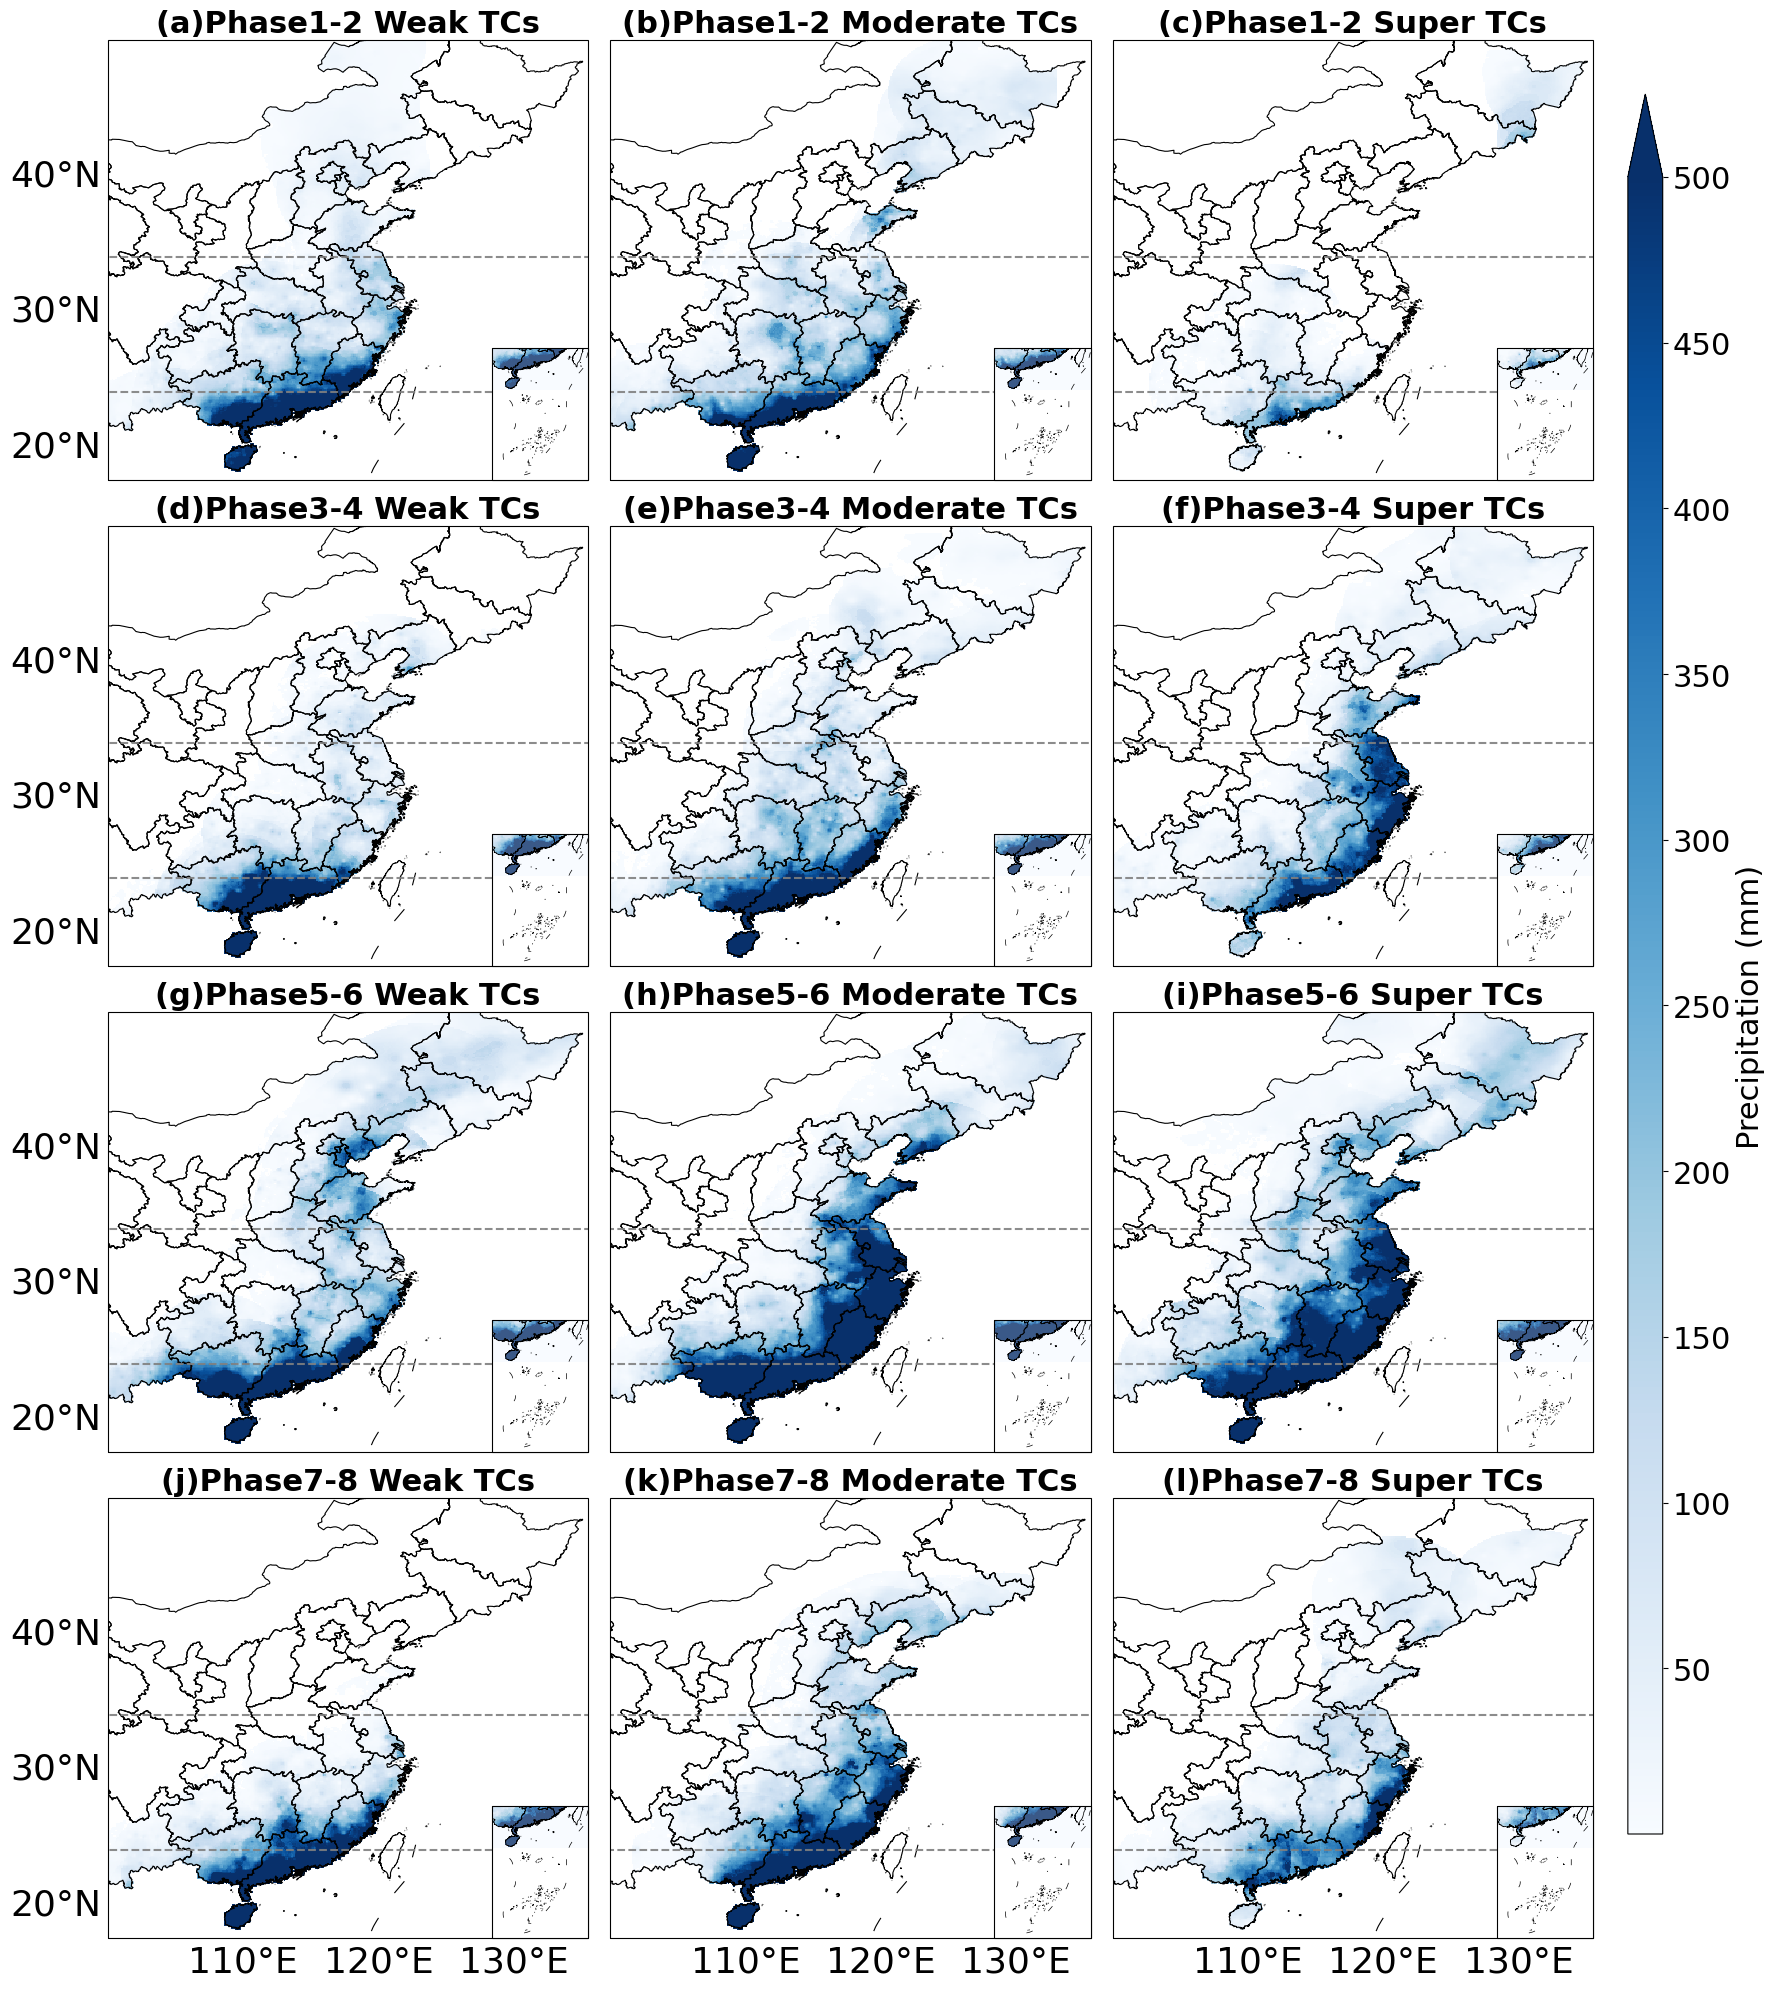

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
import cartopy.feature as cfeature
import os
from datetime import datetime
import warnings
import math
warnings.filterwarnings('ignore')


china_shape = './shapefiles/china.shp'
nine_dash_shape = './shapefiles/china_nine_dotted_line.shp'

def add_region_dividers(ax, extent=[105, 125]):
    # Draw two light gray horizontal dashed lines to roughly separate the three coastal regions
    ax.plot([extent[0], extent[1]], [24, 24],
            linestyle='--', linewidth=1.5, color='gray', alpha=0.9,
            transform=ccrs.PlateCarree())
    ax.plot([extent[0], extent[1]], [34, 34],
            linestyle='--', linewidth=1.5, color='gray', alpha=0.9,
            transform=ccrs.PlateCarree())

def _adjust_cbar_ticks(cbar, fontsize, step, ticks):
    """Helper function: adjust colorbar tick font size and spacing"""
    if fontsize is not None:
        cbar.ax.tick_params(labelsize=fontsize)
    if ticks is not None:
        cbar.set_ticks(ticks)
    elif step is not None:
        import matplotlib.ticker as mticker
        cbar.locator = mticker.MultipleLocator(step)
        cbar.update_ticks()

def plot_precipitation_multi(file_list, titles=None, ncols=2, extent=[100, 135.5, 15, 50],
                             vmax=None, figsize=None, share_colorbar=True,
                             gridline_interval=10, label_fontsize=12,
                             cbar_pad=0.05, cbar_fraction=0.02, cbar_shrink=0.9,
                             orientation='vertical',
                             cbar_tick_fontsize=None,
                             cbar_tick_step=None,
                             cbar_ticks=None,
                             subplots_adjust=None):
    """
    Plot precipitation distribution from multiple files in a grid layout (optimized).
    """
    n = len(file_list)
    nrows = math.ceil(n / ncols)
    
    if figsize is None:
        figsize = (6 * ncols, 5 * nrows)  # each subplot about 6x5 inches
    
    fig, axes = plt.subplots(nrows, ncols, subplot_kw={'projection': ccrs.PlateCarree()},
                             figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
    
    # Hide extra subplots
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    
    # Title handling
    if titles is None:
        titles = [os.path.basename(f) for f in file_list]
    else:
        assert len(titles) == n, "titles length must match file_list length"
    
    # ----- vmax handling -----
    if share_colorbar:
        if vmax is None:
            all_precip = []
            for f in file_list:
                ds = xr.open_dataset(f)
                precip = ds['prec'].isel(time=0).values
                all_precip.append(precip.flatten())
                ds.close()
            all_precip = np.concatenate(all_precip)
            vmax_global = np.percentile(all_precip[~np.isnan(all_precip)], 99.9)
            print(f"Global automatic vmax = {vmax_global:.1f} mm")
        else:
            vmax_global = vmax
        vmax_list = [vmax_global] * n
    else:
        if vmax is None:
            vmax_list = []
            for f in file_list:
                ds = xr.open_dataset(f)
                precip = ds['prec'].isel(time=0).values
                v = np.percentile(precip[~np.isnan(precip)], 99.9)
                vmax_list.append(v)
                ds.close()
            print("Automatic vmax per file:", [f"{v:.1f}" for v in vmax_list])
        elif isinstance(vmax, (int, float)):
            vmax_list = [vmax] * n
        elif isinstance(vmax, list):
            vmax_list = vmax
        else:
            raise ValueError("vmax should be None, a number, or a list")
    
    # Store plot objects for shared colorbar
    im_list = []
    
    for i, (ax, file, title, vm) in enumerate(zip(axes_flat[:n], file_list, titles, vmax_list)):
        # Read data
        ds = xr.open_dataset(file)
        precip = ds['prec'].isel(time=0)
        lon = ds.lon.values
        lat = ds.lat.values
        ds.close()
        
        # Set map extent
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Add region dividing lines
        add_region_dividers(ax, extent=[0, 180])
        
        # Add China border and nine-dash line
        ax.add_geometries(Reader(china_shape).geometries(),
                          ccrs.PlateCarree(), facecolor='none',
                          edgecolor='black', linewidth=0.8)
        ax.add_geometries(Reader(nine_dash_shape).geometries(),
                          ccrs.PlateCarree(), facecolor='none',
                          edgecolor='black', linewidth=0.8)
        
        # Plot precipitation
        cmap = plt.cm.Blues.copy()
        cmap.set_under('white')
        im = ax.pcolormesh(lon, lat, precip, cmap=cmap,
                           vmin=0.01, vmax=vm, shading='auto',
                           transform=ccrs.PlateCarree())
        im_list.append(im)
        
        # Determine subplot position in the grid
        row = i // ncols
        col = i % ncols
        # Coordinate label control: left labels for first column, bottom labels for last row
        left_labels = (col == 0)
        bottom_labels = (row == nrows - 1)
        
        # Add gridlines and control label display
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                          linewidth=0, alpha=0,
                          xlocs=mticker.MultipleLocator(gridline_interval),
                          ylocs=mticker.MultipleLocator(gridline_interval))
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = left_labels
        gl.bottom_labels = bottom_labels
        # Set label font size
        gl.xlabel_style = {'size': label_fontsize}
        gl.ylabel_style = {'size': label_fontsize}
        
        # Title
        ax.set_title(title, fontsize=22, fontweight='bold')
        
        # Add South China Sea inset map
        ax_inset = ax.inset_axes([0.75, 0.001, 0.3, 0.3], transform=ax.transAxes,
                                 projection=ccrs.PlateCarree())
        ax_inset.set_extent([106.3, 122.8, 2.6, 25.2], crs=ccrs.PlateCarree())
        ax_inset.add_geometries(Reader(china_shape).geometries(),
                                ccrs.PlateCarree(), facecolor='none',
                                edgecolor='black', linewidth=0.5)
        ax_inset.add_geometries(Reader(nine_dash_shape).geometries(),
                                ccrs.PlateCarree(), facecolor='none',
                                edgecolor='black', linewidth=0.5)
        ax_inset.pcolormesh(lon, lat, precip, cmap=cmap, vmin=0, vmax=vm,
                            shading='auto', transform=ccrs.PlateCarree(), alpha=0.8)
        
        # If not sharing a colorbar, add individual colorbar
        if not share_colorbar:
            cbar = fig.colorbar(im, ax=ax, orientation=orientation,
                                pad=cbar_pad, shrink=cbar_shrink, extend='max', aspect=25,
                                fraction=cbar_fraction)
            # Adjust tick font size and spacing
            _adjust_cbar_ticks(cbar, cbar_tick_fontsize, cbar_tick_step, cbar_ticks)
    
    if share_colorbar and im_list:
        # First apply subplot layout adjustments
        if subplots_adjust is None:
            left = 0.08 + 0.02 * (ncols-1)
            right = 0.92 - 0.02 * (ncols-1) if ncols > 1 else 0.88
            subplots_adjust = {
                'left': left,
                'right': right,
                'bottom': 0.08,
                'top': 0.95,
                'wspace': 0.15,
                'hspace': 0.2
            }
        fig.subplots_adjust(**subplots_adjust)
        
        # Get bounding boxes of all active subplots (in figure coordinates)
        bboxes = [ax.get_position() for ax in axes_flat[:n]]
        # Compute union
        x0 = min(bbox.x0 for bbox in bboxes)
        x1 = max(bbox.x1 for bbox in bboxes)
        y0 = min(bbox.y0 for bbox in bboxes)
        y1 = max(bbox.y1 for bbox in bboxes)
        
        main_width = x1 - x0
        cbar_width = main_width * cbar_fraction
        cbar_x = x1 + cbar_pad * main_width
        cbar_y = y0
        cbar_height = y1 - y0

        cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
        
        cbar = fig.colorbar(im_list[0], cax=cax, orientation=orientation, extend='max')
        cbar.set_label('Precipitation (mm)', fontsize=22)
        
        _adjust_cbar_ticks(cbar, cbar_tick_fontsize, cbar_tick_step, cbar_ticks)

    plt.tight_layout()   
    return fig


data = [
    {"file": "./02_phase1_cat1.nc", "title": "(a)Phase1-2 Weak TCs"},
    {"file": "./02_phase1_cat2.nc", "title": "(b)Phase1-2 Moderate TCs"},
    {"file": "./02_phase1_cat3.nc", "title": "(c)Phase1-2 Super TCs"},
    {"file": "./02_phase2_cat1.nc", "title": "(d)Phase3-4 Weak TCs"},
    {"file": "./02_phase2_cat2.nc", "title": "(e)Phase3-4 Moderate TCs"},
    {"file": "./02_phase2_cat3.nc", "title": "(f)Phase3-4 Super TCs"},
    {"file": "./02_phase3_cat1.nc", "title": "(g)Phase5-6 Weak TCs"},
    {"file": "./02_phase3_cat2.nc", "title": "(h)Phase5-6 Moderate TCs"},
    {"file": "./02_phase3_cat3.nc", "title": "(i)Phase5-6 Super TCs"},
    {"file": "./02_phase4_cat1.nc", "title": "(j)Phase7-8 Weak TCs"},
    {"file": "./02_phase4_cat2.nc", "title": "(k)Phase7-8 Moderate TCs"},
    {"file": "./02_phase4_cat3.nc", "title": "(l)Phase7-8 Super TCs"},
]
files = [item["file"] for item in data]
titles = [item["title"] for item in data]

fig = plot_precipitation_multi(
    files, titles=titles, ncols=3,
    extent=[100, 135.5, 17.5, 50],
    vmax=500,
    share_colorbar=True,
    gridline_interval=10,
    label_fontsize=26,
    cbar_pad=0.2,
    cbar_fraction=0.03,
    cbar_shrink=0.88,
    orientation='vertical',
    cbar_tick_fontsize=22,
    cbar_tick_step=50,
    subplots_adjust={'left':0.08, 'right':0.88, 'bottom':0.08, 'top':0.95, 'wspace':-0.5, 'hspace':0.1}
)
plt.savefig('6all.png', dpi=600, bbox_inches='tight')
plt.show()

In [5]:
# %% [markdown]
# ## Precipitation total statistics (simplified: mean, max, sum, proportion)

# %%
import xarray as xr
import pandas as pd
import numpy as np
from tabulate import tabulate

# Data list (consistent with the plotting script)
data = [
    {"file": "./02_phase1_cat1.nc", "title": "(a)Phase1-2 Weak TCs"},
    {"file": "./02_phase1_cat2.nc", "title": "(b)Phase1-2 Moderate TCs"},
    {"file": "./02_phase1_cat3.nc", "title": "(c)Phase1-2 Super TCs"},
    {"file": "./02_phase2_cat1.nc", "title": "(d)Phase3-4 Weak TCs"},
    {"file": "./02_phase2_cat2.nc", "title": "(e)Phase3-4 Moderate TCs"},
    {"file": "./02_phase2_cat3.nc", "title": "(f)Phase3-4 Super TCs"},
    {"file": "./02_phase3_cat1.nc", "title": "(g)Phase5-6 Weak TCs"},
    {"file": "./02_phase3_cat2.nc", "title": "(h)Phase5-6 Moderate TCs"},
    {"file": "./02_phase3_cat3.nc", "title": "(i)Phase5-6 Super TCs"},
    {"file": "./02_phase4_cat1.nc", "title": "(j)Phase7-8 Weak TCs"},
    {"file": "./02_phase4_cat2.nc", "title": "(k)Phase7-8 Moderate TCs"},
    {"file": "./02_phase4_cat3.nc", "title": "(l)Phase7-8 Super TCs"},
]

def simple_precip_stats(file):
    """Compute mean, max, and sum for a single file (ignoring missing values)"""
    ds = xr.open_dataset(file)
    precip = ds['prec'].isel(time=0).values
    ds.close()
    
    # Exclude NaN values
    valid = precip[~np.isnan(precip)]
    if len(valid) == 0:
        return {'avg': np.nan, 'max': np.nan, 'sum': np.nan}
    
    avg = np.mean(valid)
    max_val = np.max(valid)
    total_sum = np.sum(valid)   # direct sum of precipitation at all valid grid points
    
    return {'avg': avg, 'max': max_val, 'sum': total_sum}

# Compute for all files
results = []
for item in data:
    stats = simple_precip_stats(item['file'])
    results.append({
        'Title': item['title'],
        'Avg (mm)': stats['avg'],
        'Max (mm)': stats['max'],
        'Sum (mm)': stats['sum']
    })

# Convert to DataFrame for proportion calculation
df_stats = pd.DataFrame(results)

# Compute proportion (based on the Sum column)
total_sum = df_stats['Sum (mm)'].sum()
df_stats['Proportion (%)'] = (df_stats['Sum (mm)'] / total_sum * 100).round(2)

# Print table
print("\nPrecipitation statistics by category (with proportion):")
print(tabulate(df_stats, headers='keys', tablefmt='grid', floatfmt='.2f', showindex=False))

# Optionally save to CSV
df_stats.to_csv('precipitation_stats_with_proportion.csv', index=False, encoding='utf-8-sig')
print("\nStatistics saved to precipitation_stats_with_proportion.csv")


Precipitation statistics by category (with proportion):
+--------------------------+------------+------------+-------------+------------------+
| Title                    |   Avg (mm) |   Max (mm) |    Sum (mm) |   Proportion (%) |
+==========================+============+============+=============+==================+
| (a)Phase1-2 Weak TCs     |      16.87 |    1474.54 |  3886723.13 |             6.58 |
+--------------------------+------------+------------+-------------+------------------+
| (b)Phase1-2 Moderate TCs |      17.51 |    1393.99 |  4034105.55 |             6.82 |
+--------------------------+------------+------------+-------------+------------------+
| (c)Phase1-2 Super TCs    |       3.65 |     515.76 |   841077.77 |             1.42 |
+--------------------------+------------+------------+-------------+------------------+
| (d)Phase3-4 Weak TCs     |      13.52 |    1406.83 |  3114231.30 |             5.27 |
+--------------------------+------------+------------+---------